___

# <font color= #f6c049> **Soda Pop Project: Variational Autoencoder 1** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_03/03/2026._

___

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# General
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Run on CPU
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Models
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout
from keras.optimizers import Adam
from keras import Model

# Loss Function
from tensorflow.keras.applications import VGG19
from tensorflow.keras import Model, Input

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import ops

In [13]:
train_ds = tf.data.Dataset.load('../data/processed/train_ds')
val_ds = tf.data.Dataset.load('../data/processed/val_ds')
test_ds = tf.data.Dataset.load('../data/processed/test_ds')

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, Model

input_shape = (64, 64, 3)
latent_dim = 128   # puedes cambiarlo

In [15]:
encoder_inputs = layers.Input(shape=input_shape)

# 64x64x3
x = layers.Conv2D(64, 3, activation='relu', padding='same')(encoder_inputs)
x = layers.MaxPooling2D((2,2))(x)   # 32x32x64

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)   # 16x16x32

x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2))(x)   # 8x8x16

shape_before_flatten = tf.keras.backend.int_shape(x)

x = layers.Flatten()(x)

# Media y varianza
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

In [16]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

In [17]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(
    shape_before_flatten[1] *
    shape_before_flatten[2] *
    shape_before_flatten[3],
    activation='relu'
)(latent_inputs)

x = layers.Reshape((
    shape_before_flatten[1],
    shape_before_flatten[2],
    shape_before_flatten[3]
))(x)

# 8x8x16
x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)   # 16x16

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)   # 32x32

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)   # 64x64

decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

In [18]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        # Reconstruction loss
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(inputs, reconstruction),
                axis=(1,2)
            )
        )

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        self.add_loss(recon_loss + kl_loss)
        return reconstruction

vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

In [19]:
history = vae.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - loss: 2365.2776 - val_loss: 2144.0105
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 2070.5471 - val_loss: 2041.0287
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 1991.4901 - val_loss: 1984.5618
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 1943.4025 - val_loss: 1954.4668
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 1903.7042 - val_loss: 1921.3958
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 1882.8638 - val_loss: 1919.2764
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 1867.1938 - val_loss: 1911.8704
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 1860.5142 - val_loss: 1883.0730
Epoch 9/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 1843.9542 - val_loss: 1862.9261
Epoch 10/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 1832.7261 - val_loss: 1858.9016
Epoch 11/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - loss: 1822.5562 - val_lo

dict_keys(['loss', 'val_loss'])


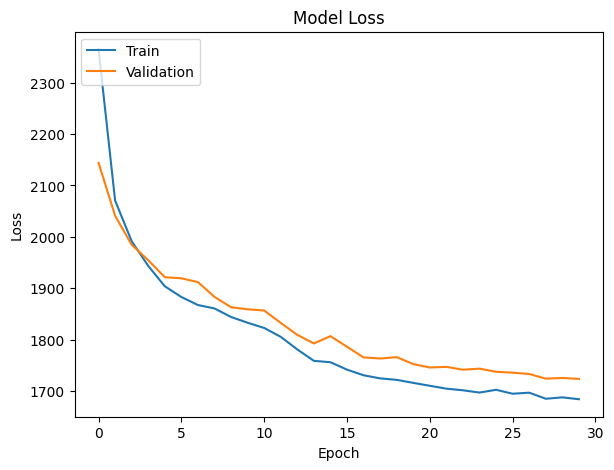

In [20]:
# Graphs
def plot_history(history):
    plt.figure(figsize=(15, 5))

    # summarize history for loss
    plt.subplot(121)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

print(history.history.keys())
plot_history(history)

In [21]:
z_random = tf.random.normal((10, latent_dim))
generated_images = decoder.predict(z_random)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


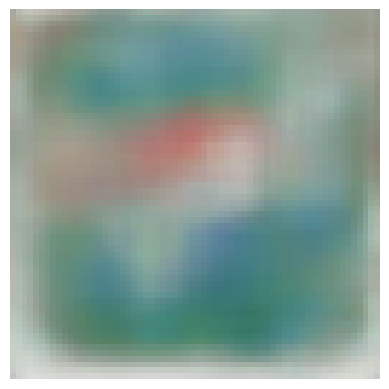

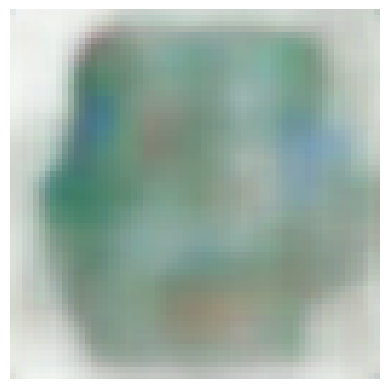

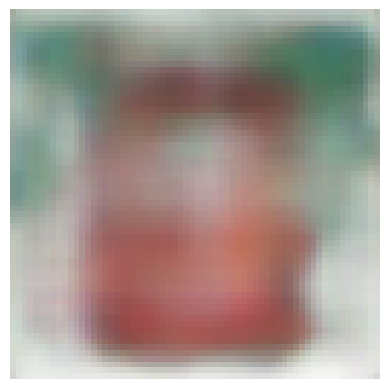

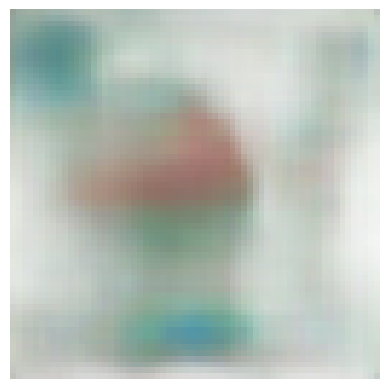

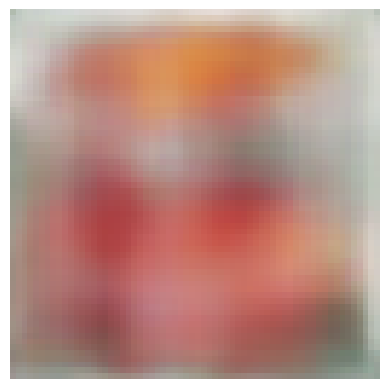

In [22]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.figure()
    plt.imshow(generated_images[i])
    plt.axis("off")
    plt.show()

In [ ]:
# Save model 
vae.save('../models/3.03-rh_VAE_sodax64.h5')

# Save the model weights
vae.save_weights('../models/3.03-rh_VAE_sodax64.weights.h5')

* Little caveat: it seems like the _.h5_ file may not be able to load the model correctly. Thus, it's preferrable to use the _.weights.h5_ file